## Les importations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Les datasets

fake_news = pd.read_csv("News_dataset/Fake.csv", dtype = {"title" : str, "text" : str, "subject" : str})
true_news = pd.read_csv("News_dataset/True.csv", dtype = {"title" : str, "text" : str, "subject" : str})
fake_news["is_fake"] = True
true_news["is_fake"] = False

true_news

,title,text,subject,date,is_fake
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",False
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",False
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",False
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",False
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",False
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",False
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",False
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",False
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",False


In [4]:
## La concatenation des datasets

true_false_news = pd.concat([fake_news, true_news], ignore_index= True)
true_false_news

,title,text,subject,date,is_fake
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",True
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",True
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",True
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",True
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",True
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",False
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",False
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",False
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",False


### les statistics descriptives

In [5]:
true_false_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   is_fake  44898 non-null  bool  
dtypes: bool(1), object(4)
memory usage: 1.4+ MB


In [6]:
true_false_news.describe()

,title,text,subject,date,is_fake
count,44898,44898,44898,44898,44898
unique,38729,38646,8,2397,2
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",True
freq,14,627,11272,182,23481


### Diagramme en barre

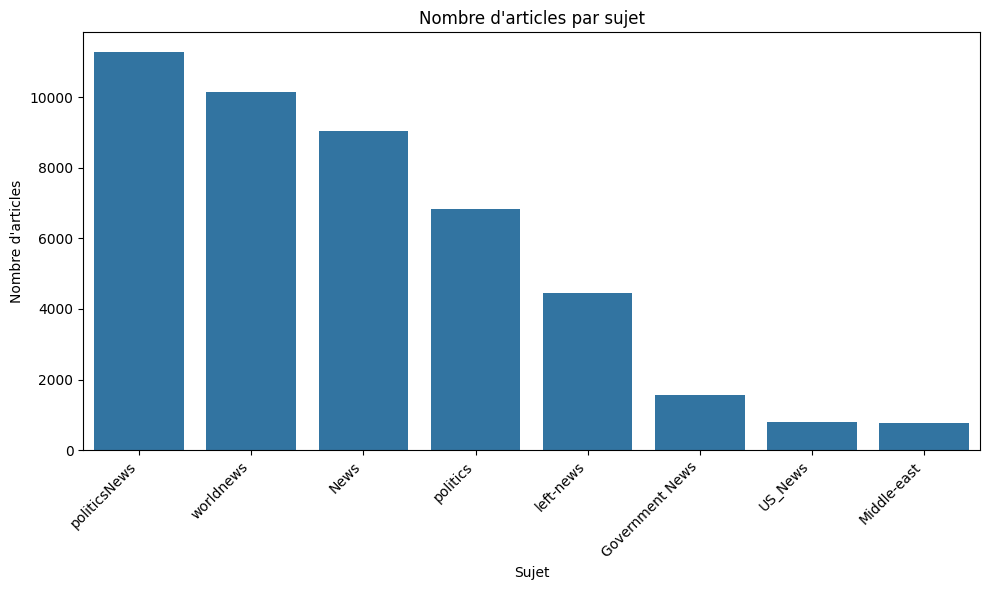

In [7]:
# Compter le nombre d'articles par sujet
subject_counts = true_false_news['subject'].value_counts()

# Créer le diagramme en barres
plt.figure(figsize=(10, 6))
sns.barplot(x=subject_counts.index, y=subject_counts.values)
plt.title('Nombre d\'articles par sujet')
plt.xlabel('Sujet')
plt.ylabel('Nombre d\'articles')
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes pour une meilleure lisibilité
plt.tight_layout()
plt.show()

### Diagramme circulaire 

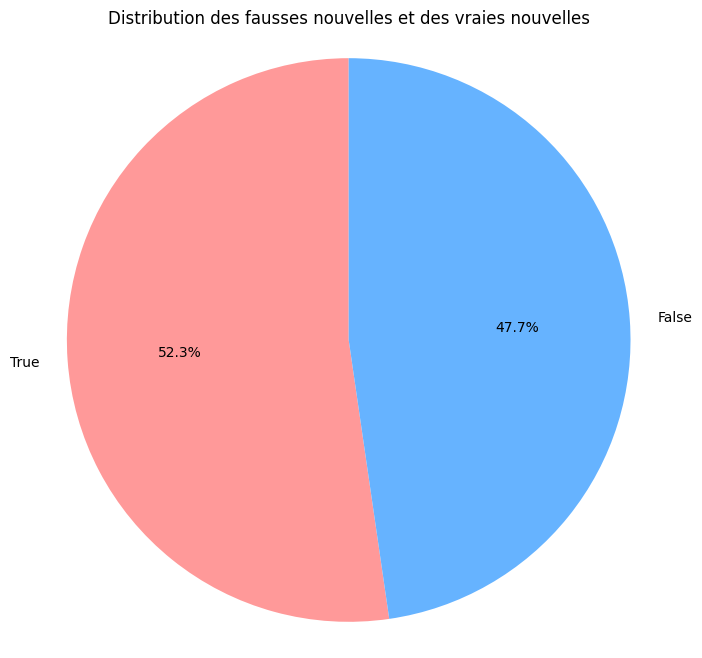

In [8]:
# Compter le nombre de "Fake" et de "Real"
is_fake_counts = true_false_news['is_fake'].value_counts()

# Créer le diagramme circulaire
plt.figure(figsize=(8, 8))
plt.pie(is_fake_counts, labels=is_fake_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution des fausses nouvelles et des vraies nouvelles')
plt.axis('equal')  # Assure que le cercle est rond
plt.show()

### diagramme à barre

/tmp/ipykernel_5341/3998696368.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=text_counts.values, palette='viridis')


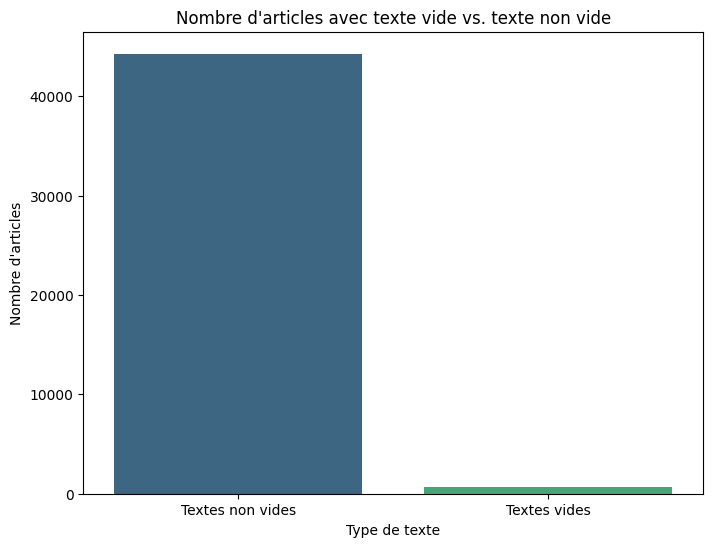

In [9]:
# Create a new column to identify empty texts
# We use str(x).strip() to handle any whitespace
true_false_news['is_text_empty'] = true_false_news['text'].apply(lambda x: len(str(x).strip()) == 0)

# Count the occurrences of empty and non-empty texts
text_counts = true_false_news['is_text_empty'].value_counts()

# Set the labels for the x-axis
labels = ['Textes non vides', 'Textes vides']

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=text_counts.values, palette='viridis')

# Add a title and labels
plt.title('Nombre d\'articles avec texte vide vs. texte non vide')
plt.xlabel('Type de texte')
plt.ylabel('Nombre d\'articles')
plt.show()

### traitement des données

In [ ]:
## Les données redondantes
true_false_news[true_false_news.duplicated].count()

title            209
text             209
subject          209
date             209
is_fake          209
is_text_empty    209
dtype: int64

In [23]:
## La suppression de ces données *
true_false_news = true_false_news.drop_duplicates()
true_false_news.describe()

,title,text,subject,date,is_fake,is_text_empty
count,44689,44689,44689,44689,44689,44689
unique,38729,38646,8,2397,2,2
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 6, 2017",True,False
freq,14,627,11220,166,23478,44058


### L'embedding

In [24]:
from sentence_transformers import SentenceTransformer

# Obtenir la liste de tous les textes à partir de la colonne 'text'
texts = true_false_news['text'].tolist()

# Charger un modèle SentenceTransformer pré-entraîné
# 'all-MiniLM-L6-v2' est un bon choix car il est rapide et efficace.
print("Chargement du modèle SentenceTransformer...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Générer les embeddings pour tous les textes
# La méthode 'encode' prend votre liste de textes et retourne une matrice de vecteurs.
print("Génération des embeddings. Cela peut prendre un certain temps...")
X_embeddings = model.encode(texts, show_progress_bar=True)
print("\nEmbeddings générés. Forme de la matrice :", X_embeddings.shape)

/home/koubra/Documents/fake_news_detector/.fake_news/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement du modèle SentenceTransformer...


/home/koubra/Documents/fake_news_detector/.fake_news/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Génération des embeddings. Cela peut prendre un certain temps...


Batches: 100%|██████████| 1397/1397 [48:59<00:00,  2.10s/it] 



Embeddings générés. Forme de la matrice : (44689, 384)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df_encoded = pd.get_dummies(true_false_news, columns=['is_fake'], drop_first=True, dtype=int)
y_labels = true_false_news['is_fake'].tolist()
df_encoded

,title,text,subject,date,is_text_empty,is_fake_True
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",False,1.0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",False,1.0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",False,1.0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",False,1.0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",False,1.0
...,...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",False,0.0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",False,0.0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",False,0.0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",False,0.0


In [26]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y_labels, test_size=0.2, random_state=42
)

In [27]:

# Initialiser et entraîner le classifieur
print("\nEntraînement du classifieur passif-actif...")
pac = PassiveAggressiveClassifier(max_iter=50, random_state=42)
pac.fit(X_train, y_train)

# Faire des prédictions et évaluer le modèle
y_pred = pac.predict(X_test)
score = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

print(f'\nPrécision avec les embeddings : {round(score * 100, 2)}%')
print('Matrice de confusion :\n', confusion)


Entraînement du classifieur passif-actif...

Précision avec les embeddings : 97.04%
Matrice de confusion :
 [[4108   92]
 [ 173 4565]]


## La phase du test

In [32]:
def verifier_fausse_nouvelle(texte_a_verifier, model_embedding, classifier):
    """
    Vérifie si une nouvelle est fausse ou réelle en utilisant les modèles entraînés.
    
    Args:
        texte_a_verifier (str): Le texte de la nouvelle à vérifier.
        model_embedding (SentenceTransformer): Le modèle d'embedding entraîné.
        classifier (PassiveAggressiveClassifier): Le classifieur entraîné.
        
    Returns:
        str: Le résultat de la prédiction ('FAKE' ou 'REAL').
    """
    # Étape 1 : Générer l'embedding pour le nouveau texte
    new_text_embedding = model_embedding.encode([texte_a_verifier])
    
    # Étape 2 : Faire la prédiction avec le classifieur entraîné
    prediction = classifier.predict(new_text_embedding)
    
    # Retourner le résultat
    return prediction[0]

In [ ]:
# Exemple de fausse nouvelle à tester
fausse_nouvelle_a_tester = """
Révélation choc : Le gouvernement a annoncé un plan secret pour interdire
complètement l'utilisation d'Internet pour tous les citoyens âgés de plus de 50 ans
afin d'améliorer la productivité nationale. Les experts disent que cela pourrait
entrer en vigueur dès la semaine prochaine sans aucun préavis.
"""


# On appelle la fonction pour vérifier la nouvelle
prediction = verifier_fausse_nouvelle(fausse_nouvelle_a_tester, model, pac)

print(f"\nLa nouvelle est classée comme : {prediction}")


La nouvelle est classée comme : False
